![Portada de la actividad](portada.jpeg)

# ESCUELA DE INGENIERÍA

## Machine Learning

### **Unidad 3**

**Integrantes:** 
*Camila Donoso Araya*

# INTRODUCCIÓN

En este trabajo se usó el dataset Store Sales - Time Series Forecasting, trabajando con train.csv. Se realizó limpieza, creación de variables, One Hot Encoding, normalización y codificación de la venta en tres categorías: baja, media y alta.

También se aplicó PCA, reduciendo la base de 116 variables a 8 componentes, conservando el 93.12% de la información. Luego se compararon cinco modelos: OPTICS, DBSCAN, Spectral Clustering, Agglomerative Clustering y K-Means.

El mejor modelo fue OPTICS con PCA, con Silhouette = 0.92. Se evidenciaron 3 grupos, dos claramente definidos y uno no totalmente separado, debido a que las ventas medias se mezclan con las ventas bajas y altas.

# DESARROLLO EVALUACIÓN 3

a) Limpieza de datos

Se realizó la limpieza del archivo train.csv, siguiendo la lógica trabajada previamente: conversión de fechas, revisión de valores faltantes, eliminación de duplicados, validación de ventas y promociones negativas, identificación de valores atípicos mediante IQR y transformación de ventas con winsorización y logaritmo.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("train.csv")
df["date"] = pd.to_datetime(df["date"])

print("Dimensiones iniciales:", df.shape)
print(df.head())
print(df.dtypes)

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nDuplicados:", df.duplicated().sum())

df = df.drop_duplicates()

df = df[df["sales"] >= 0]
df = df[df["onpromotion"] >= 0]

df["anio"] = df["date"].dt.year
df["mes"] = df["date"].dt.month
df["dia_semana"] = df["date"].dt.dayofweek
df["es_fin_semana"] = df["dia_semana"].isin([5, 6]).astype(int)

ventas_por_fecha = df.groupby("date")["sales"].mean().reset_index()

Q1 = ventas_por_fecha["sales"].quantile(0.25)
Q3 = ventas_por_fecha["sales"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = max(0, Q1 - 1.5 * IQR)
limite_superior = Q3 + 1.5 * IQR

ventas_por_fecha["outlier_fecha_iqr"] = (
    (ventas_por_fecha["sales"] < limite_inferior) |
    (ventas_por_fecha["sales"] > limite_superior)
).astype(int)

df = df.merge(
    ventas_por_fecha[["date", "outlier_fecha_iqr"]],
    on="date",
    how="left"
)

limite_superior_sales = df["sales"].quantile(0.99)

df["sales_winsor"] = df["sales"].clip(lower=0, upper=limite_superior_sales)
df["sales_log"] = np.log1p(df["sales_winsor"])
df["onpromotion_log"] = np.log1p(df["onpromotion"])

dataset_base = (
    df.groupby(["store_nbr", "family"])
    .agg(
        cantidad_registros=("sales", "size"),
        sales_total=("sales", "sum"),
        sales_mean=("sales", "mean"),
        sales_median=("sales", "median"),
        sales_std=("sales", "std"),
        sales_min=("sales", "min"),
        sales_max=("sales", "max"),
        sales_log_mean=("sales_log", "mean"),
        onpromotion_total=("onpromotion", "sum"),
        onpromotion_mean=("onpromotion", "mean"),
        onpromotion_log_mean=("onpromotion_log", "mean"),
        porcentaje_dias_promocion=("onpromotion", lambda x: (x > 0).mean()),
        porcentaje_ventas_cero=("sales", lambda x: (x == 0).mean()),
        porcentaje_fechas_outlier=("outlier_fecha_iqr", "mean")
    )
    .reset_index()
)

dataset_base["sales_std"] = dataset_base["sales_std"].fillna(0)

dataset_base["sales_cv"] = np.where(
    dataset_base["sales_mean"] > 0,
    dataset_base["sales_std"] / dataset_base["sales_mean"],
    0
)

ventas_fin_semana = (
    df.pivot_table(
        index=["store_nbr", "family"],
        columns="es_fin_semana",
        values="sales",
        aggfunc="mean",
        fill_value=0
    )
    .reset_index()
)

if 0 not in ventas_fin_semana.columns:
    ventas_fin_semana[0] = 0

if 1 not in ventas_fin_semana.columns:
    ventas_fin_semana[1] = 0

ventas_fin_semana = ventas_fin_semana.rename(
    columns={
        0: "sales_mean_dia_semana",
        1: "sales_mean_fin_semana"
    }
)

dataset_base = dataset_base.merge(
    ventas_fin_semana,
    on=["store_nbr", "family"],
    how="left"
)

ventas_mes = (
    df.pivot_table(
        index=["store_nbr", "family"],
        columns="mes",
        values="sales",
        aggfunc="mean",
        fill_value=0
    )
    .reset_index()
)

ventas_mes.columns = (
    ["store_nbr", "family"] +
    [f"sales_mean_mes_{str(col).zfill(2)}" for col in ventas_mes.columns[2:]]
)

dataset_base = dataset_base.merge(
    ventas_mes,
    on=["store_nbr", "family"],
    how="left"
)

dataset_base = dataset_base.fillna(0)

try:
    dataset_base["y_venta_categoria"] = pd.qcut(
        dataset_base["sales_mean"],
        q=3,
        labels=[0, 1, 2]
    ).astype(int)
except ValueError:
    dataset_base["y_venta_categoria"] = pd.qcut(
        dataset_base["sales_mean"].rank(method="first"),
        q=3,
        labels=[0, 1, 2]
    ).astype(int)

dataset_base["y_venta_texto"] = dataset_base["y_venta_categoria"].map({
    0: "Ventas bajas",
    1: "Ventas medias",
    2: "Ventas altas"
})

print("Dimensiones dataset_base:", dataset_base.shape)
print("\nDistribución de y:")
print(dataset_base["y_venta_texto"].value_counts())
print(dataset_base.head())

Dimensiones iniciales: (3000888, 6)
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0
id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object

Valores faltantes:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Duplicados: 0
Dimensiones dataset_base: (1782, 33)

Distribución de y:
y_venta_texto
Ventas bajas     594
Ventas altas     594
Ventas medias    594
Name: count, dtype: int64
   store_nbr      family  cantidad_registros  sales_total   sales_mean  \
0          1  AUTOMOTIVE  

b. Si es necesario aplica One Hot Encoding.

Se aplicó One Hot Encoding a las variables categóricas store_nbr y family, ya que los algoritmos de clustering necesitan variables numéricas.

In [ ]:
dataset_b = dataset_base.copy()

dataset_b["store_nbr"] = dataset_b["store_nbr"].astype(str)

variables_categoricas = ["store_nbr", "family"]

dataset_ohe = pd.get_dummies(
    dataset_b,
    columns=variables_categoricas,
    dtype=int
)

y_venta = dataset_ohe["y_venta_categoria"]
y_venta_texto = dataset_ohe["y_venta_texto"]

X_sin_normalizar = dataset_ohe.drop(
    columns=["y_venta_categoria", "y_venta_texto"]
)

print("Dimensiones antes del One Hot Encoding:", dataset_base.shape)
print("Dimensiones después del One Hot Encoding:", dataset_ohe.shape)

dataset_ohe.head()

Dimensiones antes del One Hot Encoding: (1782, 33)
Dimensiones después del One Hot Encoding: (1782, 118)
Dimensiones de X_sin_normalizar: (1782, 116)


,cantidad_registros,sales_total,sales_mean,sales_median,sales_std,sales_min,sales_max,sales_log_mean,onpromotion_total,onpromotion_mean,...,family_MAGAZINES,family_MEATS,family_PERSONAL CARE,family_PET SUPPLIES,family_PLAYERS AND ELECTRONICS,family_POULTRY,family_PREPARED FOODS,family_PRODUCE,family_SCHOOL AND OFFICE SUPPLIES,family_SEAFOOD
0,1684,5475.0,3.251188,3.0,2.759605,0.0,19.0,1.236057,14,0.008314,...,0,0,0,0,0,0,0,0,0,0
1,1684,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0,0.000000,...,0,0,0,0,0,0,0,0,0,0
2,1684,4056.0,2.408551,2.0,1.898950,0.0,12.0,1.063128,226,0.134204,...,0,0,0,0,0,0,0,0,0,0
3,1684,2673769.0,1587.748812,1674.0,726.870056,0.0,5051.0,7.224672,15864,9.420428,...,0,0,0,0,0,0,0,0,0,0
4,1684,211.0,0.125297,0.0,0.536578,0.0,8.0,0.069211,0,0.000000,...,0,0,0,0,0,0,0,0,0,0


c. Si es necesario aplicar normalización.

Se normalizaron las variables numéricas continuas con StandardScaler. Esto es necesario porque los algoritmos de distancia, densidad y PCA son sensibles a la escala de las variables, es decir la variabilidad dada por la escala puede afectar a los algoritmos, además, categorizamos las ventas en tres niveles "ventas bajas", "ventas medias" y "ventas altas". 

In [ ]:
dataset_normalizado = dataset_ohe.copy()

columnas_excluir = ["y_venta_categoria", "y_venta_texto"]

columnas_dummies = [
    col for col in dataset_normalizado.columns
    if col.startswith("store_nbr_") or col.startswith("family_")
]

columnas_continuas = [
    col for col in dataset_normalizado.columns
    if col not in columnas_excluir + columnas_dummies
]

scaler = StandardScaler()

dataset_normalizado[columnas_continuas] = scaler.fit_transform(
    dataset_normalizado[columnas_continuas]
)

X_normalizado = dataset_normalizado.drop(
    columns=["y_venta_categoria", "y_venta_texto"]
)

print("Variables continuas normalizadas:", len(columnas_continuas))
print("Variables dummies no normalizadas:", len(columnas_dummies))

dataset_normalizado.head()

Variables continuas normalizadas: 29
Variables dummies no normalizadas: 87
Dimensiones de X_normalizado: (1782, 116)


,cantidad_registros,sales_total,sales_mean,sales_median,sales_std,sales_min,sales_max,sales_log_mean,onpromotion_total,onpromotion_mean,...,family_MAGAZINES,family_MEATS,family_PERSONAL CARE,family_PET SUPPLIES,family_PLAYERS AND ELECTRONICS,family_POULTRY,family_PREPARED FOODS,family_PRODUCE,family_SCHOOL AND OFFICE SUPPLIES,family_SEAFOOD
0,0.0,-0.368688,-0.368688,-0.359387,-0.382978,0.0,-0.298379,-0.710016,-0.543415,-0.543415,...,0,0,0,0,0,0,0,0,0,0
1,0.0,-0.372069,-0.372069,-0.362590,-0.388476,0.0,-0.301582,-1.230347,-0.545156,-0.545156,...,0,0,0,0,0,0,0,0,0,0
2,0.0,-0.369564,-0.369564,-0.360455,-0.384693,0.0,-0.299559,-0.782813,-0.517047,-0.517047,...,0,0,0,0,0,0,0,0,0,0
3,0.0,1.279111,1.279111,1.424905,1.059742,0.0,0.549905,1.810949,1.427974,1.427974,...,0,0,0,0,0,0,0,0,0,0
4,0.0,-0.371939,-0.371939,-0.362590,-0.387407,0.0,-0.300233,-1.201212,-0.545156,-0.545156,...,0,0,0,0,0,0,0,0,0,0


# 2) Experimento con y sin PCA

b. Base de datos sin PCA.

In [10]:
X_sin_pca = X_normalizado.copy()

print("Base sin PCA")
print("Filas:", X_sin_pca.shape[0])
print("Columnas:", X_sin_pca.shape[1])

X_sin_pca.head()

Base sin PCA
Filas: 1782
Columnas: 116


,cantidad_registros,sales_total,sales_mean,sales_median,sales_std,sales_min,sales_max,sales_log_mean,onpromotion_total,onpromotion_mean,...,family_MAGAZINES,family_MEATS,family_PERSONAL CARE,family_PET SUPPLIES,family_PLAYERS AND ELECTRONICS,family_POULTRY,family_PREPARED FOODS,family_PRODUCE,family_SCHOOL AND OFFICE SUPPLIES,family_SEAFOOD
0,0.0,-0.368688,-0.368688,-0.359387,-0.382978,0.0,-0.298379,-0.710016,-0.543415,-0.543415,...,0,0,0,0,0,0,0,0,0,0
1,0.0,-0.372069,-0.372069,-0.362590,-0.388476,0.0,-0.301582,-1.230347,-0.545156,-0.545156,...,0,0,0,0,0,0,0,0,0,0
2,0.0,-0.369564,-0.369564,-0.360455,-0.384693,0.0,-0.299559,-0.782813,-0.517047,-0.517047,...,0,0,0,0,0,0,0,0,0,0
3,0.0,1.279111,1.279111,1.424905,1.059742,0.0,0.549905,1.810949,1.427974,1.427974,...,0,0,0,0,0,0,0,0,0,0
4,0.0,-0.371939,-0.371939,-0.362590,-0.387407,0.0,-0.300233,-1.201212,-0.545156,-0.545156,...,0,0,0,0,0,0,0,0,0,0


a. Base de datos con PCA: selecciona un número mínimo de componentes.

In [25]:
from sklearn.decomposition import PCA

pca_completo = PCA()
pca_completo.fit(X_normalizado)

varianza_explicada = pca_completo.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

tabla_pca = pd.DataFrame({
    "Componente": range(1, len(varianza_explicada) + 1),
    "Varianza_Explicada": varianza_explicada,
    "Varianza_Acumulada": varianza_acumulada
})

print(tabla_pca.head(15))

umbral_pca = 0.93

n_componentes = np.argmax(varianza_acumulada >= umbral_pca) + 1

    Componente  Varianza_Explicada  Varianza_Acumulada
0            1            0.759622            0.759622
1            2            0.082060            0.841681
2            3            0.031851            0.873532
3            4            0.020406            0.893938
4            5            0.017896            0.911835
5            6            0.009509            0.921344
6            7            0.006953            0.928297
7            8            0.002874            0.931172
8            9            0.001587            0.932759
9           10            0.001404            0.934163
10          11            0.001193            0.935356
11          12            0.001098            0.936454
12          13            0.001093            0.937547
13          14            0.001089            0.938635
14          15            0.001085            0.939721


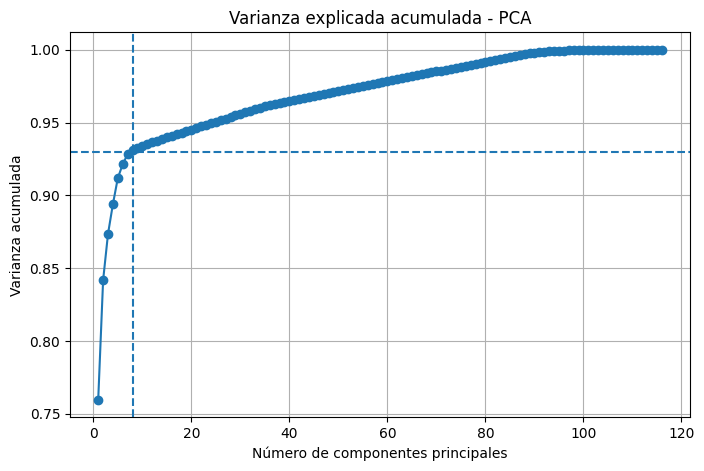

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(
    tabla_pca["Componente"],
    tabla_pca["Varianza_Acumulada"],
    marker="o"
)

plt.axhline(y=umbral_pca, linestyle="--")
plt.axvline(x=n_componentes, linestyle="--")

plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza acumulada")
plt.title("Varianza explicada acumulada - PCA")
plt.grid(True)
plt.show()

Por el método del codo, elegimos, 8 componentes principales, estos explican el 93,12% de la variabilidad total.

In [16]:
pca = PCA(n_components=n_componentes)

X_pca_array = pca.fit_transform(X_normalizado)

columnas_pca = [f"PC{i+1}" for i in range(n_componentes)]

X_con_pca = pd.DataFrame(
    X_pca_array,
    columns=columnas_pca
)

print("Base con PCA")
print("Filas:", X_con_pca.shape[0])
print("Columnas:", X_con_pca.shape[1])

X_con_pca.head()

Base con PCA
Filas: 1782
Columnas: 8


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-1.995131,0.153616,-0.993315,0.236181,-0.315910,-0.513327,-0.398820,-0.310836
1,-2.292724,1.647514,-0.585406,0.374512,1.485554,0.688690,0.226481,0.313040
2,-1.882263,-0.092279,-0.731015,0.165221,-0.192313,-0.211753,-0.167319,-0.665740
3,6.512939,-1.585266,0.610832,-0.578141,0.084194,0.190985,0.450331,0.051010
4,-2.357191,2.332162,0.639153,-0.214521,0.341023,0.299589,0.071930,0.244285


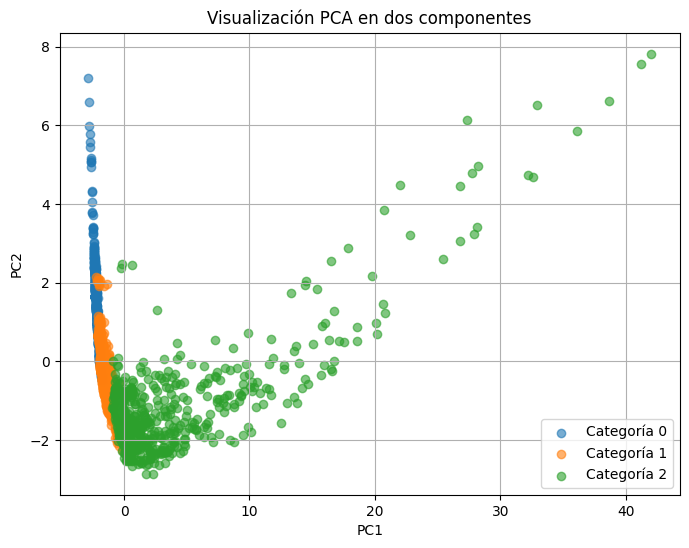

In [17]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_normalizado)

df_pca_2d = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "y_venta_categoria": y_venta,
    "y_venta_texto": y_venta_texto
})

plt.figure(figsize=(8, 6))

for categoria in sorted(df_pca_2d["y_venta_categoria"].unique()):
    datos = df_pca_2d[df_pca_2d["y_venta_categoria"] == categoria]
    plt.scatter(
        datos["PC1"],
        datos["PC2"],
        label=f"Categoría {categoria}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualización PCA en dos componentes")
plt.legend()
plt.grid(True)
plt.show()

La gráfica muestra la proyección de los datos en las dos primeras componentes principales, PC1 y PC2. Se observa que la Categoría 0 y la Categoría 1 se concentran principalmente en la zona izquierda del gráfico, con cierta superposición entre ellas. En cambio, la Categoría 2, correspondiente a ventas altas, presenta mayor dispersión y se separa más hacia valores positivos de PC1.

Sin PCA tenemos 116 variables, con PCA tenemos 8 componentes principales.

# 3) Challenge entre algoritmos (benchmarking)

a. Realiza un challange entre algoritmos entre distancia y densidad (mínimo 5 modelos).
Comentario. Se debe justificar y explicar con fundamentos cada decisión.

Seleccionamos 5 modelos

| Modelo                   | Tipo                  |
| ------------------------ | --------------------- |
| OPTICS                   | Densidad              |
| DBSCAN                   | Densidad              |
| Spectral Clustering      | Distancia / similitud |
| Agglomerative Clustering | Distancia             |
| K-Means                  | Distancia             |

y cada modelo se evaluó en dos escenarios:

| Escenario | Descripción                                                         |
| --------- | ------------------------------------------------------------------- |
| Sin PCA   | Se usaron las 116 variables originales transformadas y normalizadas |
| Con PCA   | Se usaron las 8 componentes principales seleccionadas en el Punto 2 |

Para cada algoritmo se probaron distintas configuraciones de parámetros. La selección del mejor resultado se hizo automáticamente usando el coeficiente de Silhouette, tomando el valor más alto como mejor desempeño. Esta métrica se eligió porque permite evaluar si los datos dentro de un mismo grupo son similares entre sí y si los grupos están bien separados entre ellos.


In [26]:
import pandas as pd
import numpy as np
import warnings

from sklearn.cluster import OPTICS, DBSCAN, SpectralClustering, AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")

bases = {
    "Sin PCA": X_sin_pca,
    "Con PCA": X_con_pca
}

tipos_modelo = {
    "OPTICS": "Densidad",
    "DBSCAN": "Densidad",
    "Spectral Clustering": "Distancia / Similitud",
    "Agglomerative Clustering": "Distancia",
    "K-Means": "Distancia"
}

def calcular_metricas(X, labels):
    labels = np.array(labels)
    mascara = labels != -1
    labels_validos = labels[mascara]

    if len(np.unique(labels_validos)) < 2:
        return np.nan, np.nan, np.nan

    if hasattr(X, "iloc"):
        X_validos = X.iloc[mascara]
    else:
        X_validos = X[mascara]

    sil = silhouette_score(X_validos, labels_validos)
    db = davies_bouldin_score(X_validos, labels_validos)
    ch = calinski_harabasz_score(X_validos, labels_validos)

    return sil, db, ch

def obtener_eps_grid(X, min_samples):
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X)

    distancias, _ = nn.kneighbors(X)
    k_dist = distancias[:, -1]

    eps_grid = np.quantile(k_dist, [0.60, 0.70, 0.80, 0.85, 0.90, 0.95])
    eps_grid = np.unique(np.round(eps_grid, 4))
    eps_grid = eps_grid[eps_grid > 0]

    return eps_grid

resultados = []

for nombre_base, X in bases.items():

    mejor_sil = -np.inf
    mejor_db = np.nan
    mejor_ch = np.nan
    mejor_params = None
    mejor_clusters = None

    for min_samples in [5, 10, 20]:
        for xi in [0.03, 0.05, 0.10]:
            modelo = OPTICS(min_samples=min_samples, xi=xi, cluster_method="xi")
            labels = modelo.fit_predict(X)

            sil, db, ch = calcular_metricas(X, labels)

            if not np.isnan(sil) and sil > mejor_sil:
                mejor_sil = sil
                mejor_db = db
                mejor_ch = ch
                mejor_params = {"min_samples": min_samples, "xi": xi}
                mejor_clusters = len(set(labels[labels != -1]))

    resultados.append({
        "Base": nombre_base,
        "Modelo": "OPTICS",
        "Tipo": tipos_modelo["OPTICS"],
        "Parametros": str(mejor_params),
        "N_Clusters": mejor_clusters,
        "Silhouette": mejor_sil,
        "Davies_Bouldin": mejor_db,
        "Calinski_Harabasz": mejor_ch
    })

    mejor_sil = -np.inf
    mejor_db = np.nan
    mejor_ch = np.nan
    mejor_params = None
    mejor_clusters = None

    for min_samples in [5, 10, 20]:
        eps_grid = obtener_eps_grid(X, min_samples)

        for eps in eps_grid:
            modelo = DBSCAN(eps=eps, min_samples=min_samples)
            labels = modelo.fit_predict(X)

            sil, db, ch = calcular_metricas(X, labels)

            if not np.isnan(sil) and sil > mejor_sil:
                mejor_sil = sil
                mejor_db = db
                mejor_ch = ch
                mejor_params = {"eps": float(eps), "min_samples": min_samples}
                mejor_clusters = len(set(labels[labels != -1]))

    resultados.append({
        "Base": nombre_base,
        "Modelo": "DBSCAN",
        "Tipo": tipos_modelo["DBSCAN"],
        "Parametros": str(mejor_params),
        "N_Clusters": mejor_clusters,
        "Silhouette": mejor_sil,
        "Davies_Bouldin": mejor_db,
        "Calinski_Harabasz": mejor_ch
    })

    mejor_sil = -np.inf
    mejor_db = np.nan
    mejor_ch = np.nan
    mejor_params = None
    mejor_clusters = None

    for k in range(2, 11):
        modelo = SpectralClustering(
            n_clusters=k,
            affinity="nearest_neighbors",
            n_neighbors=10,
            assign_labels="kmeans",
            random_state=42
        )

        labels = modelo.fit_predict(X)

        sil, db, ch = calcular_metricas(X, labels)

        if not np.isnan(sil) and sil > mejor_sil:
            mejor_sil = sil
            mejor_db = db
            mejor_ch = ch
            mejor_params = {"n_clusters": k}
            mejor_clusters = len(np.unique(labels))

    resultados.append({
        "Base": nombre_base,
        "Modelo": "Spectral Clustering",
        "Tipo": tipos_modelo["Spectral Clustering"],
        "Parametros": str(mejor_params),
        "N_Clusters": mejor_clusters,
        "Silhouette": mejor_sil,
        "Davies_Bouldin": mejor_db,
        "Calinski_Harabasz": mejor_ch
    })

    mejor_sil = -np.inf
    mejor_db = np.nan
    mejor_ch = np.nan
    mejor_params = None
    mejor_clusters = None

    for k in range(2, 11):
        modelo = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = modelo.fit_predict(X)

        sil, db, ch = calcular_metricas(X, labels)

        if not np.isnan(sil) and sil > mejor_sil:
            mejor_sil = sil
            mejor_db = db
            mejor_ch = ch
            mejor_params = {"n_clusters": k, "linkage": "ward"}
            mejor_clusters = len(np.unique(labels))

    resultados.append({
        "Base": nombre_base,
        "Modelo": "Agglomerative Clustering",
        "Tipo": tipos_modelo["Agglomerative Clustering"],
        "Parametros": str(mejor_params),
        "N_Clusters": mejor_clusters,
        "Silhouette": mejor_sil,
        "Davies_Bouldin": mejor_db,
        "Calinski_Harabasz": mejor_ch
    })

    mejor_sil = -np.inf
    mejor_db = np.nan
    mejor_ch = np.nan
    mejor_params = None
    mejor_clusters = None

    for k in range(2, 11):
        modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = modelo.fit_predict(X)

        sil, db, ch = calcular_metricas(X, labels)

        if not np.isnan(sil) and sil > mejor_sil:
            mejor_sil = sil
            mejor_db = db
            mejor_ch = ch
            mejor_params = {"n_clusters": k}
            mejor_clusters = len(np.unique(labels))

    resultados.append({
        "Base": nombre_base,
        "Modelo": "K-Means",
        "Tipo": tipos_modelo["K-Means"],
        "Parametros": str(mejor_params),
        "N_Clusters": mejor_clusters,
        "Silhouette": mejor_sil,
        "Davies_Bouldin": mejor_db,
        "Calinski_Harabasz": mejor_ch
    })

resultados_benchmark = pd.DataFrame(resultados)

tabla_sin_pca = resultados_benchmark[resultados_benchmark["Base"] == "Sin PCA"].copy()
tabla_con_pca = resultados_benchmark[resultados_benchmark["Base"] == "Con PCA"].copy()

tabla_sin_pca = tabla_sin_pca.rename(columns={
    "Parametros": "Parametros_Sin_PCA",
    "N_Clusters": "Clusters_Sin_PCA",
    "Silhouette": "Silhouette_Sin_PCA",
    "Davies_Bouldin": "Davies_Bouldin_Sin_PCA",
    "Calinski_Harabasz": "Calinski_Harabasz_Sin_PCA"
}).drop(columns=["Base"])

tabla_con_pca = tabla_con_pca.rename(columns={
    "Parametros": "Parametros_Con_PCA",
    "N_Clusters": "Clusters_Con_PCA",
    "Silhouette": "Silhouette_Con_PCA",
    "Davies_Bouldin": "Davies_Bouldin_Con_PCA",
    "Calinski_Harabasz": "Calinski_Harabasz_Con_PCA"
}).drop(columns=["Base"])

tabla_final = tabla_sin_pca.merge(
    tabla_con_pca,
    on=["Modelo", "Tipo"],
    how="inner"
)

tabla_final["Orden"] = tabla_final["Modelo"].map({
    "OPTICS": 1,
    "DBSCAN": 2,
    "Spectral Clustering": 3,
    "Agglomerative Clustering": 4,
    "K-Means": 5
})

tabla_final["Mejor_Base"] = np.where(
    tabla_final["Silhouette_Con_PCA"] > tabla_final["Silhouette_Sin_PCA"],
    "Con PCA",
    "Sin PCA"
)

columnas_redondear = [
    "Silhouette_Sin_PCA",
    "Davies_Bouldin_Sin_PCA",
    "Calinski_Harabasz_Sin_PCA",
    "Silhouette_Con_PCA",
    "Davies_Bouldin_Con_PCA",
    "Calinski_Harabasz_Con_PCA"
]

tabla_final[columnas_redondear] = tabla_final[columnas_redondear].round(2)

tabla_final = tabla_final.sort_values("Orden").drop(columns="Orden")

tabla_final = tabla_final[[
    "Modelo",
    "Tipo",
    "Parametros_Sin_PCA",
    "Clusters_Sin_PCA",
    "Silhouette_Sin_PCA",
    "Davies_Bouldin_Sin_PCA",
    "Calinski_Harabasz_Sin_PCA",
    "Parametros_Con_PCA",
    "Clusters_Con_PCA",
    "Silhouette_Con_PCA",
    "Davies_Bouldin_Con_PCA",
    "Calinski_Harabasz_Con_PCA",
    "Mejor_Base"
]]

display(tabla_final)

,Modelo,Tipo,Parametros_Sin_PCA,Clusters_Sin_PCA,Silhouette_Sin_PCA,Davies_Bouldin_Sin_PCA,Calinski_Harabasz_Sin_PCA,Parametros_Con_PCA,Clusters_Con_PCA,Silhouette_Con_PCA,Davies_Bouldin_Con_PCA,Calinski_Harabasz_Con_PCA,Mejor_Base
0,OPTICS,Densidad,"{'min_samples': 10, 'xi': 0.05}",3,0.69,0.63,730.47,"{'min_samples': 20, 'xi': 0.1}",3,0.92,0.11,4941.95,Con PCA
1,DBSCAN,Densidad,"{'eps': 2.7975, 'min_samples': 10}",2,0.69,0.38,358.37,"{'eps': 2.1043, 'min_samples': 10}",2,0.74,0.32,443.67,Con PCA
2,Spectral Clustering,Distancia / Similitud,{'n_clusters': 2},2,0.30,1.29,552.41,{'n_clusters': 10},10,0.25,1.04,446.42,Sin PCA
3,Agglomerative Clustering,Distancia,"{'n_clusters': 2, 'linkage': 'ward'}",2,0.63,0.85,1482.30,"{'n_clusters': 2, 'linkage': 'ward'}",2,0.74,0.70,1943.90,Con PCA
4,K-Means,Distancia,{'n_clusters': 2},2,0.74,0.64,1899.14,{'n_clusters': 2},2,0.78,0.60,2213.69,Con PCA


Se construyó una tabla comparativa donde cada modelo aparece con su resultado sin PCA y con PCA, permitiendo comparar directamente el efecto de aplicar reducción de dimensionalidad.

# 4) Evalúa el modelo con métricas de evaluación.

### a. Con las métricas vistas evalúa los modelos.

Para evaluar los modelos se utilizaron tres métricas: Silhouette, Davies-Bouldin y Calinski-Harabasz. Silhouette se interpreta mejor cuando es más alto, Davies-Bouldin cuando es más bajo, y Calinski-Harabasz cuando es más alto.

Al comparar los resultados sin PCA y con PCA, se observa que aplicar PCA mejora el desempeño en la mayoría de los modelos. En particular, OPTICS mejora de forma muy marcada: su Silhouette pasa de 0.69 a 0.92, Davies-Bouldin baja de 0.63 a 0.11, y Calinski-Harabasz aumenta de 730.47 a 4941.95. Esto nos indica que, después de reducir la dimensionalidad, los grupos quedan mucho más compactos y separados, entonces reducir la dimensionalidad debe ser un paso obligatorio.

La comparación entre modelos de densidad y modelos de distancia, se observa que el mejor resultado global lo obtuvo un modelo de densidad: OPTICS (porque tiene la mayor Silhouette 0.92) con PCA. En resumen este modelo presentó el mayor Silhouette, el menor Davies-Bouldin y el mayor Calinski-Harabasz de toda la comparación. Por lo tanto, fue el modelo campeón.

### b. Escoge un modelo en función a las métricas de evaluación.
e acuerdo con las métricas de evaluación, el modelo seleccionado es:

OPTICS con PCA

Este modelo obtuvo los mejores resultados globales:

| Métrica            | Resultado OPTICS con PCA | Interpretación                                                                                     |
| ------------------ | -----------------------: | -------------------------------------------------------------------------------------------------- |
| Silhouette         |                     0.92 | Es el valor más alto de todos los modelos       |
| Davies-Bouldin     |                     0.11 | Es el valor más bajo, lo que indica clusters compactos y bien diferenciados                        |
| Calinski-Harabasz  |                  4941.95 | Es el valor más alto, lo que nos indica buena separación entre grupos frente a la variabilidad interna |
| Número de clusters |                        3 | Nos coincide con una segmentación interpretable de ventas bajas, medias y altas                        |


### c. Dado que sabes cuál es la variable “y” (por las unidades anteriores) haz un análisis si el algoritmo de clustering está diferenciado correctamente.

Conocemos la variable y_ventas, podemos comparar los clusters generados por OPTICS con PCA contra las categorías reales: ventas bajas, ventas medias y ventas altas.

,Modelo,Base,Parametros,N_Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,OPTICS,Con PCA,"min_samples=20, xi=0.1",3,0.924233,0.10887,4941.952228


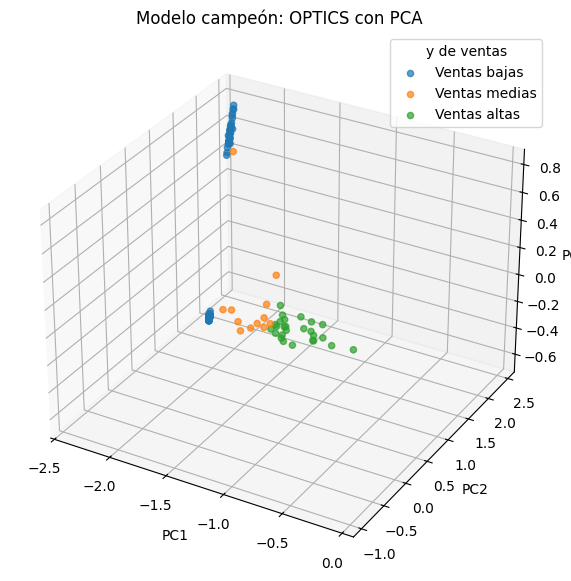

y_ventas,Ventas altas,Ventas bajas,Ventas medias
Cluster,,,
0,0,33,1
1,26,0,11
2,0,53,0


In [24]:
from sklearn.cluster import OPTICS
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

modelo_campeon = OPTICS(
    min_samples=20,
    xi=0.1,
    cluster_method="xi"
)

labels_campeon = modelo_campeon.fit_predict(X_con_pca)

mascara_validos = labels_campeon != -1

X_eval = X_con_pca.loc[mascara_validos].copy()
labels_eval = labels_campeon[mascara_validos]

y_texto = pd.Series(y_venta_texto).reset_index(drop=True)
y_eval = y_texto[mascara_validos].values

metricas_campeon = pd.DataFrame({
    "Modelo": ["OPTICS"],
    "Base": ["Con PCA"],
    "Parametros": ["min_samples=20, xi=0.1"],
    "N_Clusters": [len(np.unique(labels_eval))],
    "Silhouette": [silhouette_score(X_eval, labels_eval)],
    "Davies_Bouldin": [davies_bouldin_score(X_eval, labels_eval)],
    "Calinski_Harabasz": [calinski_harabasz_score(X_eval, labels_eval)]
})

display(metricas_campeon)

df_grafica = X_eval.copy()
df_grafica["Cluster"] = labels_eval
df_grafica["y_ventas"] = y_eval

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for categoria in df_grafica["y_ventas"].unique():
    datos = df_grafica[df_grafica["y_ventas"] == categoria]
    ax.scatter(
        datos["PC1"],
        datos["PC2"],
        datos["PC3"],
        label=categoria,
        alpha=0.7
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Modelo campeón: OPTICS con PCA")
ax.legend(title="y de ventas")
plt.show()

tabla_cluster_y = pd.crosstab(
    df_grafica["Cluster"],
    df_grafica["y_ventas"]
)

display(tabla_cluster_y)

Como podemos observar en la tabla anterior el algoritmo diferencia bastante bien las ventas bajas y las ventas altas, pero no separa perfectamente las ventas medias:

- El Cluster 2 está formado únicamente por ventas bajas.
- El Cluster 0 también representa principalmente ventas bajas.
- El Cluster 1 agrupa principalmente ventas altas, aunque incluye algunas ventas medias.
Así las ventas medias no forman un cluster propio, sino que aparecen mezcladas con ventas bajas y ventas altas.

Podemos concluir que el modelo sí logra una buena diferenciación, especialmente entre ventas bajas y ventas altas. Sin embargo, la separación no es perfecta porque la categoría de ventas medias no esta bien determinada no esta totalmente aislada. 

Esto tambien lo observamos en la gráfica, los puntos de ventas bajas y ventas altas tienden a ubicarse en zonas diferentes del espacio PCA, mientras que las ventas medias se encuentran entre ambas categorías, mostrando solapamiento.

# CONCLUSIONES

1) Primeramente, ACP mejoró el rendimiento de la mayoría de los modelos, porque nos redujo la base de 116 variables a 8 componentes, conservando aproximadamente el 93.12% de la información. Ejemplo, en OPTICS, el Silhouette aumentó de 0.69 sin PCA a 0.92 con PCA, y en K-Means aumentó de 0.74 a 0.78.

2) El mejor modelo fue OPTICS con PCA, porque obtuvo el mejor desempeño global: Silhouette = 0.92, Davies-Bouldin = 0.11 y Calinski-Harabasz = 4941.95. Estos resultados nos indican clusters bien separados, compactos que es justamente lo que buscamos.

3) Los grupos no quedaron totalmente separados porque la categoría de ventas medias funciona como una zona intermedia entre ventas bajas y altas. En la tabla cruzada, el Cluster 1 agrupó 26 ventas altas y 11 ventas medias, mostrando que las ventas medias se mezclan parcialmente con las ventas altas.

# BIBIOGRAFÍA

- Universidad Mayor. (s. f.). Unidad 3: Algoritmos no-supervisados. Machine Learning [Material de clase]. Universidad Mayor.

- Ding, C., & He, X. (2004). K-means clustering via principal component analysis. Proceedings of the Twenty-First International Conference on Machine Learning. https://doi.org/10.1145/1015330.1015408

- Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: A review and recent developments. Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences, 374(2065), 20150202.

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

